In [15]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Print TensorFlow version for compatibility check
print(tf.__version__)

# Features: [Area, Distance, Parking]
# These are your input features that might affect the price (y)
# Expanded dataset: Features - [Area, Distance, Parking]
X = np.array([
    [30, 15, 0],
    [35, 14, 0],
    [40, 12, 1],
    [45, 11, 1],
    [50, 10, 1],
    [55, 9, 1],
    [60, 8, 1],
    [65, 7, 1],
    [70, 6, 1],
    [75, 5, 1],
    [80, 4, 1],
    [85, 3, 1],
    [90, 2, 1],
    [95, 1.5, 1],
    [100, 1, 1],
    [55, 14, 0],
    [65, 10, 1],
    [70, 9, 0],
    [85, 4, 0],
    [95, 3, 1]
])

# Simulated prices with a pattern: more area, closer, parking = higher price
y = np.array([
    5000, 5500, 7000, 7500, 9000, 9500, 11000, 11500, 13000, 13500,
    15000, 16000, 17000, 17500, 18500, 8800, 11500, 12000, 15000, 17000
])


2.19.0


In [17]:
len(X)

20

In [19]:
# MinMax Scaling normalizes features to the 0–1 range.
# Neural networks converge faster when input features are normalized.
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# Scale y
y = y.reshape(-1, 1)  # Reshape to 2D for scaler
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y)

# Then split

print("Scaled Features:\n", X_scaled)

Scaled Features:
 [[0.         1.         0.        ]
 [0.07142857 0.92857143 0.        ]
 [0.14285714 0.78571429 1.        ]
 [0.21428571 0.71428571 1.        ]
 [0.28571429 0.64285714 1.        ]
 [0.35714286 0.57142857 1.        ]
 [0.42857143 0.5        1.        ]
 [0.5        0.42857143 1.        ]
 [0.57142857 0.35714286 1.        ]
 [0.64285714 0.28571429 1.        ]
 [0.71428571 0.21428571 1.        ]
 [0.78571429 0.14285714 1.        ]
 [0.85714286 0.07142857 1.        ]
 [0.92857143 0.03571429 1.        ]
 [1.         0.         1.        ]
 [0.35714286 0.92857143 0.        ]
 [0.5        0.64285714 1.        ]
 [0.57142857 0.57142857 0.        ]
 [0.78571429 0.21428571 0.        ]
 [0.92857143 0.14285714 1.        ]]


In [21]:
# Determine split index
split_index = int(0.8 * len(X_scaled))  # 80% for training

# Proper train/test split without overlap
X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]
y_train = y_scaled[:split_index]
y_test = y_scaled[split_index:]
# Display number of training and test samples
print("Units for training: ", len(X_train))
print("Units for testing: ", len(X_test))


Units for training:  16
Units for testing:  4


In [31]:
# For consistent results across runs, we set a seed
tf.random.set_seed(42)
# Build a simple feed-forward neural network
# The input layer connects to a hidden layer with 16 neurons and ReLU activation
# Output layer has 1 neuron (for regression prediction)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
# - Loss: Mean Absolute Error (MAE), ideal for regression problems
# - Optimizer: Adam (adaptive moment estimation), a smart choice for faster and more stable convergence
#   It adjusts the learning rate dynamically per parameter
model.compile(
    loss=tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001), # high LR for faster learning on small dataset
    metrics=['mae']
)

# Train the model
# - 300 epochs give the model plenty of time to learn patterns in a small dataset
# - verbose=2 shows training progress for each epoch
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=20)
model.fit(X_train, y_train, epochs=300, verbose=2, callbacks=[callback])

Epoch 1/300
1/1 - 2s - 2s/step - loss: 0.2920 - mae: 0.2920
Epoch 2/300
1/1 - 0s - 146ms/step - loss: 0.2829 - mae: 0.2829
Epoch 3/300
1/1 - 0s - 163ms/step - loss: 0.2737 - mae: 0.2737
Epoch 4/300
1/1 - 0s - 139ms/step - loss: 0.2645 - mae: 0.2645
Epoch 5/300
1/1 - 0s - 167ms/step - loss: 0.2560 - mae: 0.2560
Epoch 6/300
1/1 - 0s - 158ms/step - loss: 0.2481 - mae: 0.2481
Epoch 7/300
1/1 - 0s - 153ms/step - loss: 0.2403 - mae: 0.2403
Epoch 8/300
1/1 - 0s - 152ms/step - loss: 0.2321 - mae: 0.2321
Epoch 9/300
1/1 - 0s - 163ms/step - loss: 0.2237 - mae: 0.2237
Epoch 10/300
1/1 - 0s - 153ms/step - loss: 0.2162 - mae: 0.2162
Epoch 11/300
1/1 - 0s - 166ms/step - loss: 0.2088 - mae: 0.2088
Epoch 12/300
1/1 - 0s - 157ms/step - loss: 0.2016 - mae: 0.2016
Epoch 13/300
1/1 - 0s - 153ms/step - loss: 0.1944 - mae: 0.1944
Epoch 14/300
1/1 - 0s - 166ms/step - loss: 0.1866 - mae: 0.1866
Epoch 15/300
1/1 - 0s - 164ms/step - loss: 0.1787 - mae: 0.1787
Epoch 16/300
1/1 - 0s - 160ms/step - loss: 0.1708 - 

In [25]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae}")
# Evaluate the model on the test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.0000e+00 - loss: 0.3932
Test MAE: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.0000e+00 - loss: 0.3932


[0.3931894898414612, 0.0]

In [27]:
# Input from user with error handling and better prompts
try:
    area = int(input("🏠 Enter Area in Square Meters: "))
    distance = int(input("📍 Enter Distance from Work (km): "))
    
    # Handle parking input with yes/no conversion to 1/0
    parking_input = input("🚗 Does it have Parking? (yes/no): ").strip().lower()
    parking = 1 if parking_input in ['yes', 'y', 'true', '1'] else 0

    # Scale the input features
    input_data = np.array([[area, distance, parking]])
    input_scaled = scaler.transform(input_data)

    # Predict scaled price
    prediction_scaled = model.predict(input_scaled)

    # Inverse transform to get actual price
    prediction_actual = y_scaler.inverse_transform(prediction_scaled)[0][0]

    # Print formatted result
    print(f"\n💰 Predicted Price:")
    print(f"Area: {area} sqm | Distance: {distance} km | Parking: {'Yes' if parking else 'No'}")
    print(f"Estimated Rent: ₱{prediction_actual:,.2f}")

except ValueError:
    print("⚠️ Invalid input. Please enter numeric values for area and distance.")


🏠 Enter Area in Square Meters:  75
📍 Enter Distance from Work (km):  5
🚗 Does it have Parking? (yes/no):  1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step

💰 Predicted Price:
Area: 75 sqm | Distance: 5 km | Parking: Yes
Estimated Rent: ₱8,566.94


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


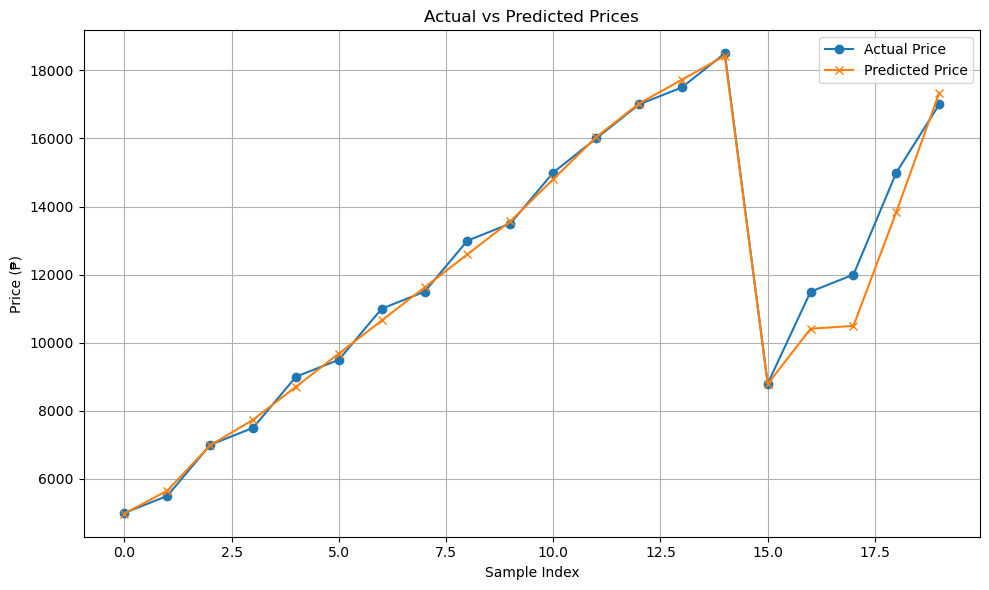

In [102]:
# Predict on the full scaled X (for all data points)
y_pred_scaled = model.predict(X_scaled)

# Inverse transform both predictions and actual labels to get back to original price scale
y_pred_actual = y_scaler.inverse_transform(y_pred_scaled)
y_actual = y_scaler.inverse_transform(y_scaled)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(y_actual, label='Actual Price', marker='o')
plt.plot(y_pred_actual, label='Predicted Price', marker='x')
plt.title("Actual vs Predicted Prices")
plt.xlabel("Sample Index")
plt.ylabel("Price (₱)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#IMAGE CLASSIFICATION MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # for 10 classes
])

In [ ]:
#SIMPLE REGRESSION
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # No activation on output
])
